# Drug Synergy Prediction Workflow
## Using Machine Learning & Quantum Computing
---

# PHASE 1: DATA LOADING & EDA

In [2]:
# Step 1.1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor, VotingRegressor, StackingRegressor
from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.feature_selection import VarianceThreshold
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostRegressor
import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [3]:
# Step 1.2: Load Dataset
df = pd.read_csv('Final_Model_Dataset.csv', low_memory=False)
print(f"Dataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns")

Dataset loaded: 304,943 rows × 61 columns


In [4]:
# Step 1.3: Basic EDA
print("=" * 60)
print("BASIC EDA")
print("=" * 60)
print(f"\n📊 Shape: {df.shape}")
print(f"\n📋 Column Names:\n{df.columns.tolist()}")
print(f"\n🔢 Data Types:\n{df.dtypes.value_counts()}")
print(f"\n📈 First 5 rows:")
df.head()

BASIC EDA

📊 Shape: (304943, 61)

📋 Column Names:
['CELLNAME', 'mean_score', 'std_score', 'mean_growth', 'n_obs', 'A_NSC_x', 'A_Release', 'A_Structure Source', 'A_CAS', 'A_Molecular Formula in DIS', 'A_Molecular Weight (nearest integer)', 'A_dtpname:USAN', 'A_dtpname:Brand Name', 'A_dtpname:Chemical Name', 'A_dtpname:9th C.I.', 'A_dtpname:8th C.I.', 'A_ID', 'A_Molecule', 'A_dtpname:VAN', 'A_dtpname:INN:BAN', 'A_dtpname:German Name', 'A_Molecular Weight (calculated from formula)', 'A_NSC_y', 'A_mean_growth', 'A_std_growth', 'A_mean_score', 'A_std_score', 'A_growth_min', 'A_growth_max', 'A_growth_range', 'B_NSC_x', 'B_Release', 'B_Structure Source', 'B_CAS', 'B_Molecular Formula in DIS', 'B_Molecular Weight (nearest integer)', 'B_dtpname:USAN', 'B_dtpname:Brand Name', 'B_dtpname:Chemical Name', 'B_dtpname:9th C.I.', 'B_dtpname:8th C.I.', 'B_ID', 'B_Molecule', 'B_dtpname:VAN', 'B_dtpname:INN:BAN', 'B_dtpname:German Name', 'B_Molecular Weight (calculated from formula)', 'B_NSC_y', 'B_mean_

,CELLNAME,mean_score,std_score,mean_growth,n_obs,A_NSC_x,A_Release,A_Structure Source,A_CAS,A_Molecular Formula in DIS,...,B_std_score,B_growth_min,B_growth_max,B_growth_range,MSIScore,LoHFraction,WGD,CIN,Ploidy,Aneuploidy
0,786-0,1.222222,3.993050,21.140000,9,740.0,June 2016,NCI/DIS 2D,59-05-2,C20H22N8O5,...,10.69249,-99.23,183.92,283.15,NaN,NaN,NaN,NaN,NaN,NaN
1,A498,-5.777778,6.476453,65.963333,9,740.0,June 2016,NCI/DIS 2D,59-05-2,C20H22N8O5,...,10.69249,-99.23,183.92,283.15,NaN,NaN,NaN,NaN,NaN,NaN
2,A549/ATCC,-5.888889,8.535872,61.244444,9,740.0,June 2016,NCI/DIS 2D,59-05-2,C20H22N8O5,...,10.69249,-99.23,183.92,283.15,NaN,NaN,NaN,NaN,NaN,NaN
3,ACHN,-3.444444,5.101743,60.908889,9,740.0,June 2016,NCI/DIS 2D,59-05-2,C20H22N8O5,...,10.69249,-99.23,183.92,283.15,NaN,NaN,NaN,NaN,NaN,NaN
4,BT-549,-14.555556,22.046038,70.074444,9,740.0,June 2016,NCI/DIS 2D,59-05-2,C20H22N8O5,...,10.69249,-99.23,183.92,283.15,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
# Describe statistics
df.describe()

,mean_score,std_score,mean_growth,n_obs,A_NSC_x,A_Molecular Weight (nearest integer),A_ID,A_Molecular Weight (calculated from formula),A_NSC_y,A_mean_growth,...,B_std_score,B_growth_min,B_growth_max,B_growth_range,MSIScore,LoHFraction,WGD,CIN,Ploidy,Aneuploidy
count,304943.000000,304943.000000,304943.000000,304943.000000,300700.000000,290169.000000,300700.000000,9056.000000,304943.000000,304943.000000,...,304943.000000,304943.000000,304943.000000,304943.000000,0.0,0.0,0.0,0.0,0.0,0.0
mean,-2.437275,8.762202,71.579441,9.416330,178486.753525,409.538286,178486.753525,463.155975,178788.369551,72.059369,...,12.344329,-98.476624,188.627189,287.103813,NaN,NaN,NaN,NaN,NaN,NaN
std,7.106459,6.457232,28.964710,1.719591,240507.164754,366.939557,240507.164754,91.163146,240131.194936,12.166518,...,2.405246,1.869006,27.263515,28.014291,NaN,NaN,NaN,NaN,NaN,NaN
min,-146.555556,0.440959,-98.493333,9.000000,740.000000,76.000000,740.000000,259.260000,740.000000,34.029551,...,7.990368,-100.000000,114.573000,206.913000,NaN,NaN,NaN,NaN,NaN,NaN
25%,-5.444444,5.049752,55.853333,9.000000,18509.000000,216.000000,18509.000000,421.300000,18509.000000,62.796553,...,10.674489,-99.820000,168.295000,267.485000,NaN,NaN,NaN,NaN,NaN,NaN
50%,-2.222222,7.108289,77.548889,9.000000,71423.000000,286.000000,71423.000000,475.350000,77213.000000,72.631456,...,11.927037,-99.020000,184.470000,283.920000,NaN,NaN,NaN,NaN,NaN,NaN
75%,0.888889,10.295630,93.826667,9.000000,226080.000000,454.000000,226080.000000,529.520000,226080.000000,83.617004,...,13.560196,-98.410000,200.000000,298.455000,NaN,NaN,NaN,NaN,NaN,NaN
max,127.111111,108.316665,179.904444,30.000000,761432.000000,2841.000000,761432.000000,835.930000,761432.000000,89.880361,...,20.036267,-88.912000,275.980000,375.830000,NaN,NaN,NaN,NaN,NaN,NaN


TARGET ANALYSIS (mean_score)


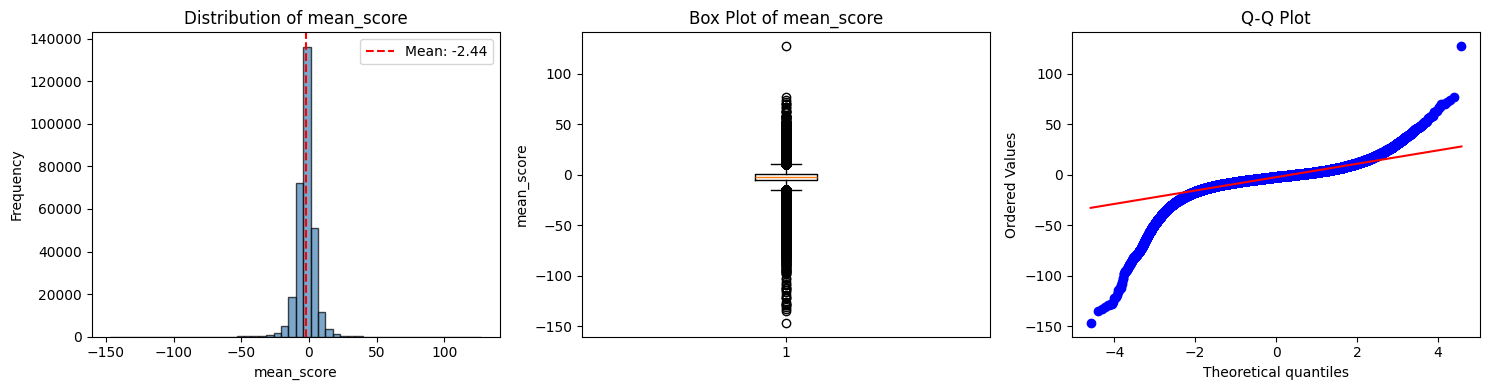


📊 Statistics:
   Mean: -2.4373
   Std: 7.1065
   Min: -146.5556
   Max: 127.1111
   Skewness: -1.3623
   Kurtosis: 20.7188


In [6]:
# Step 1.4: Target Analysis
print("=" * 60)
print("TARGET ANALYSIS (mean_score)")
print("=" * 60)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Distribution
axes[0].hist(df['mean_score'].dropna(), bins=50, edgecolor='black', alpha=0.7, color='steelblue')
axes[0].set_xlabel('mean_score')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of mean_score')
axes[0].axvline(df['mean_score'].mean(), color='red', linestyle='--', label=f'Mean: {df["mean_score"].mean():.2f}')
axes[0].legend()

# Box plot
axes[1].boxplot(df['mean_score'].dropna())
axes[1].set_ylabel('mean_score')
axes[1].set_title('Box Plot of mean_score')

# QQ plot for normality check
from scipy import stats
stats.probplot(df['mean_score'].dropna(), dist="norm", plot=axes[2])
axes[2].set_title('Q-Q Plot')

plt.tight_layout()
plt.show()

print(f"\n📊 Statistics:")
print(f"   Mean: {df['mean_score'].mean():.4f}")
print(f"   Std: {df['mean_score'].std():.4f}")
print(f"   Min: {df['mean_score'].min():.4f}")
print(f"   Max: {df['mean_score'].max():.4f}")
print(f"   Skewness: {df['mean_score'].skew():.4f}")
print(f"   Kurtosis: {df['mean_score'].kurtosis():.4f}")

MISSING VALUES ANALYSIS

📊 Columns with missing values: 40
                                              Missing Count   Missing %
MSIScore                                             304943  100.000000
LoHFraction                                          304943  100.000000
WGD                                                  304943  100.000000
CIN                                                  304943  100.000000
Aneuploidy                                           304943  100.000000
Ploidy                                               304943  100.000000
B_dtpname:German Name                                298017   97.728756
B_dtpname:VAN                                        297252   97.477889
A_Molecular Weight (calculated from formula)         295887   97.030265
A_dtpname:German Name                                288313   94.546522
B_dtpname:INN:BAN                                    267850   87.836087
A_dtpname:VAN                                        253279   83.057817
A_dtp

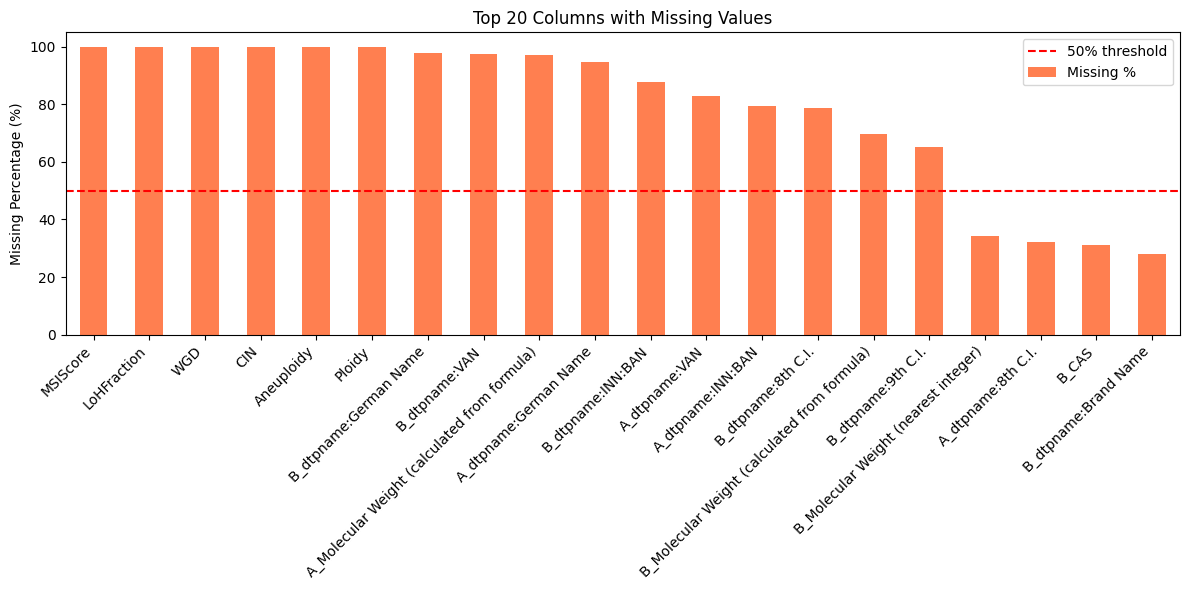

In [7]:
# Step 1.5: Missing Values Analysis
print("=" * 60)
print("MISSING VALUES ANALYSIS")
print("=" * 60)

missing = df.isnull().sum()
missing_pct = (missing / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

print(f"\n📊 Columns with missing values: {len(missing_df)}")
print(missing_df.head(15))

# Visualize missing values
if len(missing_df) > 0:
    fig, ax = plt.subplots(figsize=(12, 6))
    missing_df.head(20)['Missing %'].plot(kind='bar', ax=ax, color='coral')
    ax.set_ylabel('Missing Percentage (%)')
    ax.set_title('Top 20 Columns with Missing Values')
    ax.axhline(y=50, color='red', linestyle='--', label='50% threshold')
    ax.legend()
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

# PHASE 2: DATA PREPROCESSING

In [8]:
# Step 2.1: Select Numeric Columns
print("=" * 60)
print("SELECTING NUMERIC COLUMNS")
print("=" * 60)

# Identify object columns
object_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"\n🔤 Object columns to drop: {object_cols}")

# Select only numeric columns
df_numeric = df.select_dtypes(include=[np.number]).copy()
print(f"\n✅ Numeric columns retained: {df_numeric.shape[1]}")
print(f"   New shape: {df_numeric.shape}")

SELECTING NUMERIC COLUMNS

🔤 Object columns to drop: ['CELLNAME', 'A_Release', 'A_Structure Source', 'A_CAS', 'A_Molecular Formula in DIS', 'A_dtpname:USAN', 'A_dtpname:Brand Name', 'A_dtpname:Chemical Name', 'A_dtpname:9th C.I.', 'A_dtpname:8th C.I.', 'A_Molecule', 'A_dtpname:VAN', 'A_dtpname:INN:BAN', 'A_dtpname:German Name', 'B_Release', 'B_Structure Source', 'B_CAS', 'B_Molecular Formula in DIS', 'B_dtpname:USAN', 'B_dtpname:Brand Name', 'B_dtpname:Chemical Name', 'B_dtpname:9th C.I.', 'B_dtpname:8th C.I.', 'B_Molecule', 'B_dtpname:VAN', 'B_dtpname:INN:BAN', 'B_dtpname:German Name']

✅ Numeric columns retained: 34
   New shape: (304943, 34)


In [9]:
# Step 2.2: Handle Missing Values
print("=" * 60)
print("HANDLING MISSING VALUES")
print("=" * 60)

# Calculate missing percentage
missing_pct = (df_numeric.isnull().sum() / len(df_numeric)) * 100

# Drop columns with >50% missing
cols_to_drop = missing_pct[missing_pct > 50].index.tolist()
print(f"\n❌ Dropping {len(cols_to_drop)} columns with >50% missing values")
if cols_to_drop:
    print(f"   Columns: {cols_to_drop}")

df_clean = df_numeric.drop(columns=cols_to_drop)

# Impute remaining with median
remaining_missing = df_clean.isnull().sum().sum()
print(f"\n🔧 Remaining missing values to impute: {remaining_missing:,}")

for col in df_clean.columns:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)

print(f"✅ After imputation - Missing values: {df_clean.isnull().sum().sum()}")
print(f"   Shape: {df_clean.shape}")

HANDLING MISSING VALUES

❌ Dropping 8 columns with >50% missing values
   Columns: ['A_Molecular Weight (calculated from formula)', 'B_Molecular Weight (calculated from formula)', 'MSIScore', 'LoHFraction', 'WGD', 'CIN', 'Ploidy', 'Aneuploidy']

🔧 Remaining missing values to impute: 143,253
✅ After imputation - Missing values: 0
   Shape: (304943, 26)


In [10]:
# Step 2.3: Smart Downsampling
print("=" * 60)
print("SMART DOWNSAMPLING")
print("=" * 60)

# Create bins for stratified sampling
def create_score_bins(score):
    if score < -10:
        return 'Very Low'
    elif score < 0:
        return 'Low'
    elif score < 10:
        return 'Medium'
    elif score < 20:
        return 'High'
    else:
        return 'Very High'

df_clean['score_bin'] = df_clean['mean_score'].apply(create_score_bins)

print("\n📊 Distribution before sampling:")
print(df_clean['score_bin'].value_counts())

# Stratified sampling - take equal samples from each bin
samples_per_bin = 8000
sampled_dfs = []

for bin_name in df_clean['score_bin'].unique():
    bin_df = df_clean[df_clean['score_bin'] == bin_name]
    n_samples = min(samples_per_bin, len(bin_df))
    sampled_dfs.append(bin_df.sample(n=n_samples, random_state=42))

df_sampled = pd.concat(sampled_dfs, ignore_index=True)
df_sampled = df_sampled.drop(columns=['score_bin'])

print(f"\n✅ After stratified sampling:")
print(f"   Original: {len(df_clean):,} rows")
print(f"   Sampled: {len(df_sampled):,} rows")

SMART DOWNSAMPLING

📊 Distribution before sampling:
score_bin
Low          182619
Medium        87384
Very Low      26049
High           7182
Very High      1709
Name: count, dtype: int64

✅ After stratified sampling:
   Original: 304,943 rows
   Sampled: 32,891 rows


In [11]:
# Step 2.4: Remove Duplicates
print("=" * 60)
print("REMOVING DUPLICATES")
print("=" * 60)

before = len(df_sampled)
df_sampled = df_sampled.drop_duplicates()
after = len(df_sampled)

print(f"   Before: {before:,} rows")
print(f"   After: {after:,} rows")
print(f"   Removed: {before - after:,} duplicates")

REMOVING DUPLICATES
   Before: 32,891 rows
   After: 32,891 rows
   Removed: 0 duplicates


CORRELATION CHECK

🔍 Columns with >0.95 correlation: 6
   Removing: ['A_ID', 'A_NSC_y', 'A_growth_range', 'B_ID', 'B_NSC_y', 'B_growth_range']

✅ Final preprocessed shape: (32891, 20)


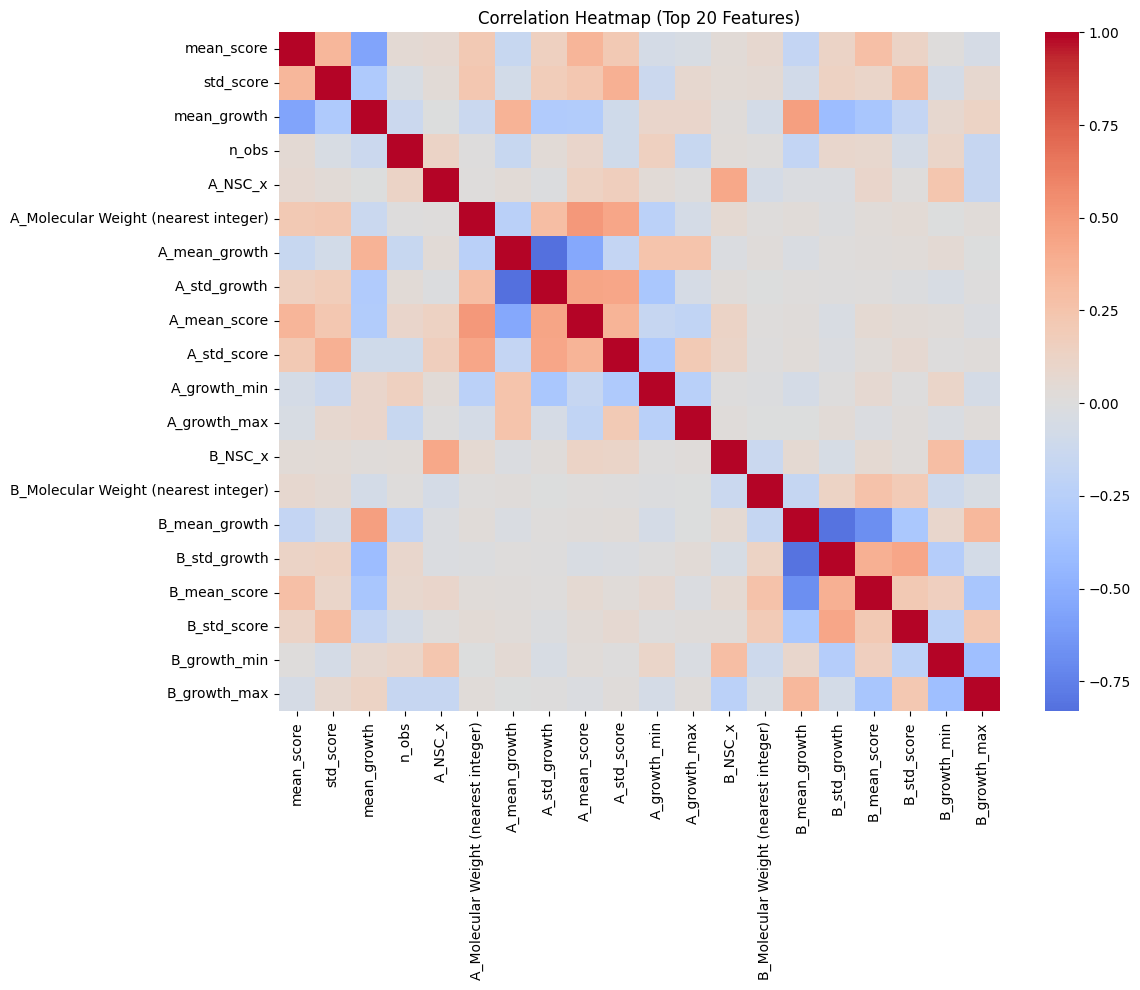

In [12]:
# Step 2.5: Correlation Check
print("=" * 60)
print("CORRELATION CHECK")
print("=" * 60)

# Compute correlation matrix
corr_matrix = df_sampled.corr().abs()

# Find highly correlated pairs
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_cols = [column for column in upper.columns if any(upper[column] > 0.95)]

print(f"\n🔍 Columns with >0.95 correlation: {len(high_corr_cols)}")
if high_corr_cols:
    print(f"   Removing: {high_corr_cols}")
    df_final = df_sampled.drop(columns=high_corr_cols)
else:
    df_final = df_sampled.copy()

print(f"\n✅ Final preprocessed shape: {df_final.shape}")

# Correlation heatmap (sample of features)
plt.figure(figsize=(12, 10))
sample_cols = df_final.columns[:20] if len(df_final.columns) > 20 else df_final.columns
sns.heatmap(df_final[sample_cols].corr(), annot=False, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap (Top 20 Features)')
plt.tight_layout()
plt.show()

# PHASE 3: FEATURE ENGINEERING

In [13]:
# Step 3.1: Define X and y
print("=" * 60)
print("DEFINING FEATURES AND TARGET")
print("=" * 60)

X = df_final.drop(columns=['mean_score'])
y = df_final['mean_score']

print(f"✅ Features (X): {X.shape}")
print(f"✅ Target (y): {y.shape}")

DEFINING FEATURES AND TARGET
✅ Features (X): (32891, 19)
✅ Target (y): (32891,)


In [14]:
# Step 3.2: Train-Test Split
print("=" * 60)
print("TRAIN-TEST SPLIT")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"✅ Training set: {X_train.shape[0]:,} samples")
print(f"✅ Test set: {X_test.shape[0]:,} samples")

TRAIN-TEST SPLIT
✅ Training set: 26,312 samples
✅ Test set: 6,579 samples


In [15]:
# Step 3.3: Feature Scaling
print("=" * 60)
print("FEATURE SCALING")
print("=" * 60)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"✅ Scaling complete (StandardScaler)")
print(f"   Train mean: {X_train_scaled.mean():.6f}")
print(f"   Train std: {X_train_scaled.std():.6f}")

FEATURE SCALING
✅ Scaling complete (StandardScaler)
   Train mean: 0.000000
   Train std: 1.000000


In [16]:
# Step 3.4: Feature Selection (Variance Threshold)
print("=" * 60)
print("FEATURE SELECTION")
print("=" * 60)

selector = VarianceThreshold(threshold=0.01)
X_train_selected = selector.fit_transform(X_train_scaled)
X_test_selected = selector.transform(X_test_scaled)

selected_features = X.columns[selector.get_support()].tolist()

print(f"✅ Features before: {X_train_scaled.shape[1]}")
print(f"✅ Features after variance threshold: {X_train_selected.shape[1]}")
print(f"   Removed: {X_train_scaled.shape[1] - X_train_selected.shape[1]} low-variance features")

FEATURE SELECTION
✅ Features before: 19
✅ Features after variance threshold: 19
   Removed: 0 low-variance features


# PHASE 4: NORMAL MACHINE LEARNING

In [17]:
# Helper function for evaluation
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    """Train and evaluate a model, returning metrics."""
    model.fit(X_train, y_train)
    
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    
    metrics = {
        'Model': model_name,
        'Train R²': r2_score(y_train, y_train_pred),
        'Test R²': r2_score(y_test, y_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_train, y_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_test, y_test_pred)),
        'Train MAE': mean_absolute_error(y_train, y_train_pred),
        'Test MAE': mean_absolute_error(y_test, y_test_pred),
    }
    metrics['Overfit Gap'] = metrics['Train R²'] - metrics['Test R²']
    
    return metrics, y_test_pred

results = []

In [18]:
# Step 4.1: XGBoost Baseline
print("=" * 60)
print("TRAINING XGBOOST BASELINE")
print("=" * 60)

xgb_model = xgb.XGBRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1
)

xgb_metrics, xgb_pred = evaluate_model(
    xgb_model, X_train_selected, X_test_selected, y_train, y_test, 'XGBoost'
)
results.append(xgb_metrics)

print(f"✅ XGBoost Results:")
print(f"   Train R²: {xgb_metrics['Train R²']:.4f}")
print(f"   Test R²: {xgb_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {xgb_metrics['Overfit Gap']:.4f}")

TRAINING XGBOOST BASELINE
✅ XGBoost Results:
   Train R²: 0.8281
   Test R²: 0.7308
   Overfit Gap: 0.0973


In [19]:
# Step 4.2: Random Forest
print("=" * 60)
print("TRAINING RANDOM FOREST")
print("=" * 60)

rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf_metrics, rf_pred = evaluate_model(
    rf_model, X_train_selected, X_test_selected, y_train, y_test, 'Random Forest'
)
results.append(rf_metrics)

print(f"✅ Random Forest Results:")
print(f"   Train R²: {rf_metrics['Train R²']:.4f}")
print(f"   Test R²: {rf_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {rf_metrics['Overfit Gap']:.4f}")

TRAINING RANDOM FOREST
✅ Random Forest Results:
   Train R²: 0.9152
   Test R²: 0.7143
   Overfit Gap: 0.2009


In [20]:
# Step 4.3: LightGBM
print("=" * 60)
print("TRAINING LIGHTGBM")
print("=" * 60)

lgb_model = lgb.LGBMRegressor(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)

lgb_metrics, lgb_pred = evaluate_model(
    lgb_model, X_train_selected, X_test_selected, y_train, y_test, 'LightGBM'
)
results.append(lgb_metrics)

print(f"✅ LightGBM Results:")
print(f"   Train R²: {lgb_metrics['Train R²']:.4f}")
print(f"   Test R²: {lgb_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {lgb_metrics['Overfit Gap']:.4f}")

TRAINING LIGHTGBM
✅ LightGBM Results:
   Train R²: 0.7986
   Test R²: 0.7280
   Overfit Gap: 0.0706


In [21]:
# Step 4.4: Evaluate All Models
print("=" * 60)
print("MODEL COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

MODEL COMPARISON
        Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
      XGBoost  0.828144 0.730839    5.558638   7.005187   3.993462  4.857237     0.097306
Random Forest  0.915223 0.714279    3.904146   7.217460   2.847050  4.931242     0.200944
     LightGBM  0.798645 0.728020    6.016830   7.041773   4.294377  4.903716     0.070625


In [ ]:
# Step 4.5: Cross-Validation
print("=" * 60)
print("5-FOLD CROSS-VALIDATION")
print("=" * 60)

cv_results = {}
for name, model in [('XGBoost', xgb_model), ('Random Forest', rf_model), ('LightGBM', lgb_model)]:
    cv_scores = cross_val_score(model, X_train_selected, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = {'Mean R²': cv_scores.mean(), 'Std': cv_scores.std()}
    print(f"{name}: Mean R² = {cv_scores.mean():.4f} (±{cv_scores.std():.4f})")

5-FOLD CROSS-VALIDATION
XGBoost: Mean R² = 0.7250 (±0.0033)


In [ ]:
# Step 4.6: Select Best Model
best_model_name = results_df.loc[results_df['Test R²'].idxmax(), 'Model']
print(f"\n🏆 Best Model (by Test R²): {best_model_name}")


🏆 Best Model (by Test R²): XGBoost


# PHASE 5: ADVANCED MACHINE LEARNING

In [ ]:
# Step 5.1: Hyperparameter Tuning
print("=" * 60)
print("HYPERPARAMETER TUNING (XGBoost)")
print("=" * 60)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [3, 5, 7, 10],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.1, 1],
    'reg_lambda': [0, 0.1, 1]
}

xgb_tuned = xgb.XGBRegressor(random_state=42, n_jobs=-1)

random_search = RandomizedSearchCV(
    xgb_tuned, param_dist, n_iter=20, cv=3, 
    scoring='r2', random_state=42, n_jobs=-1, verbose=1
)

random_search.fit(X_train_selected, y_train)

print(f"\n✅ Best Parameters: {random_search.best_params_}")
print(f"✅ Best CV Score: {random_search.best_score_:.4f}")

# Evaluate tuned model
tuned_metrics, tuned_pred = evaluate_model(
    random_search.best_estimator_, X_train_selected, X_test_selected, 
    y_train, y_test, 'XGBoost Tuned'
)
results.append(tuned_metrics)

HYPERPARAMETER TUNING (XGBoost)
Fitting 3 folds for each of 20 candidates, totalling 60 fits

✅ Best Parameters: {'subsample': 0.6, 'reg_lambda': 0.1, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
✅ Best CV Score: 0.7300


In [ ]:
# Step 5.2: CatBoost
print("=" * 60)
print("TRAINING CATBOOST")
print("=" * 60)

cat_model = CatBoostRegressor(
    iterations=300,
    depth=6,
    learning_rate=0.1,
    random_state=42,
    verbose=0
)

cat_metrics, cat_pred = evaluate_model(
    cat_model, X_train_selected, X_test_selected, y_train, y_test, 'CatBoost'
)
results.append(cat_metrics)

print(f"✅ CatBoost Results:")
print(f"   Train R²: {cat_metrics['Train R²']:.4f}")
print(f"   Test R²: {cat_metrics['Test R²']:.4f}")
print(f"   Overfit Gap: {cat_metrics['Overfit Gap']:.4f}")

TRAINING CATBOOST
✅ CatBoost Results:
   Train R²: 0.7723
   Test R²: 0.7245
   Overfit Gap: 0.0478


In [ ]:
# Step 5.3: Ensemble Methods
print("=" * 60)
print("ENSEMBLE METHODS")
print("=" * 60)

# Voting Regressor
voting_model = VotingRegressor([
    ('xgb', xgb.XGBRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)),
    ('lgb', lgb.LGBMRegressor(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1, verbose=-1)),
    ('cat', CatBoostRegressor(iterations=200, depth=6, random_state=42, verbose=0))
])

voting_metrics, voting_pred = evaluate_model(
    voting_model, X_train_selected, X_test_selected, y_train, y_test, 'Voting Ensemble'
)
results.append(voting_metrics)

print(f"✅ Voting Ensemble Results:")
print(f"   Train R²: {voting_metrics['Train R²']:.4f}")
print(f"   Test R²: {voting_metrics['Test R²']:.4f}")

# Stacking Regressor
stacking_model = StackingRegressor(
    estimators=[
        ('xgb', xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1)),
        ('lgb', lgb.LGBMRegressor(n_estimators=100, max_depth=5, random_state=42, n_jobs=-1, verbose=-1)),
        ('rf', RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
    ],
    final_estimator=Ridge(alpha=1.0),
    n_jobs=-1
)

stacking_metrics, stacking_pred = evaluate_model(
    stacking_model, X_train_selected, X_test_selected, y_train, y_test, 'Stacking Ensemble'
)
results.append(stacking_metrics)

print(f"✅ Stacking Ensemble Results:")
print(f"   Train R²: {stacking_metrics['Train R²']:.4f}")
print(f"   Test R²: {stacking_metrics['Test R²']:.4f}")

ENSEMBLE METHODS
✅ Voting Ensemble Results:
   Train R²: 0.8506
   Test R²: 0.7405
✅ Stacking Ensemble Results:
   Train R²: 0.8099
   Test R²: 0.7249


LEARNING CURVES


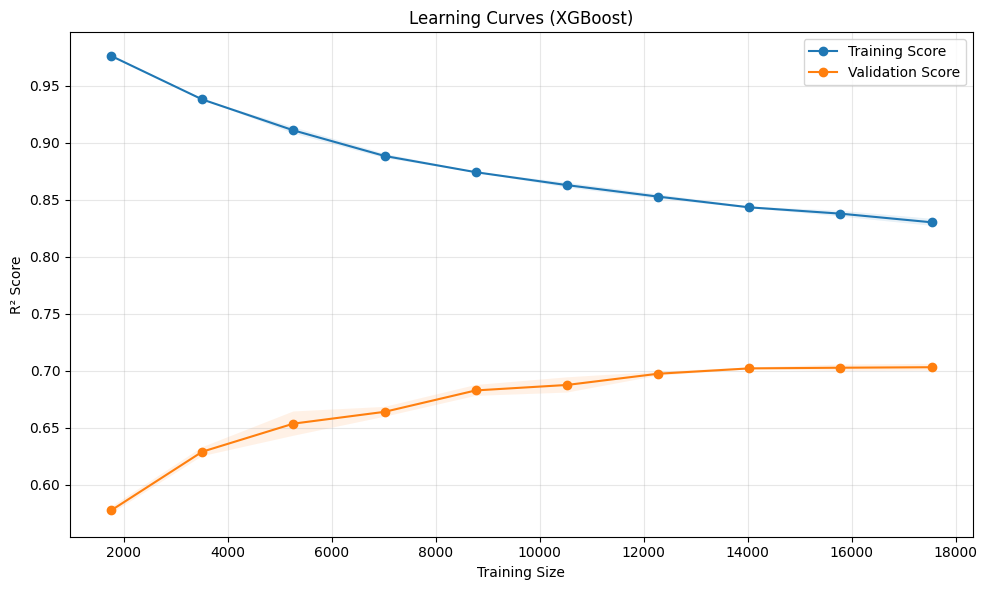

In [ ]:
# Step 5.5: Learning Curves
print("=" * 60)
print("LEARNING CURVES")
print("=" * 60)

from sklearn.model_selection import learning_curve

train_sizes, train_scores, val_scores = learning_curve(
    xgb.XGBRegressor(n_estimators=100, max_depth=5, random_state=42),
    X_train_selected, y_train, 
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=3, scoring='r2', n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', label='Training Score')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', label='Validation Score')
plt.fill_between(train_sizes, train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1)
plt.fill_between(train_sizes, val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1)
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.title('Learning Curves (XGBoost)')
plt.legend(loc='best')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# PHASE 6: QUANTUM COMPUTING

In [ ]:
# Step 6.1: Prepare Quantum Data
print("=" * 60)
print("PREPARING QUANTUM DATA")
print("=" * 60)

# Get feature importance from best classical model
feature_importance = pd.DataFrame({
    'feature': selected_features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print("Top 10 Important Features:")
print(feature_importance.head(10))

# Select top 4 features for quantum (computational constraints)
n_quantum_features = 4
top_features_idx = feature_importance.head(n_quantum_features).index.tolist()

# Sample for quantum (limit due to computational cost)
n_quantum_samples = 500
np.random.seed(42)
quantum_indices = np.random.choice(len(X_train_selected), n_quantum_samples, replace=False)

X_quantum_train = X_train_selected[quantum_indices][:, :n_quantum_features]
y_quantum_train = y_train.iloc[quantum_indices].values

# Test set (smaller)
n_quantum_test = 100
quantum_test_indices = np.random.choice(len(X_test_selected), n_quantum_test, replace=False)
X_quantum_test = X_test_selected[quantum_test_indices][:, :n_quantum_features]
y_quantum_test = y_test.iloc[quantum_test_indices].values

print(f"\n✅ Quantum Training set: {X_quantum_train.shape}")
print(f"✅ Quantum Test set: {X_quantum_test.shape}")

# Scale to [0, π] for rotation gates
from sklearn.preprocessing import MinMaxScaler
quantum_scaler = MinMaxScaler(feature_range=(0, np.pi))
X_quantum_train_scaled = quantum_scaler.fit_transform(X_quantum_train)
X_quantum_test_scaled = quantum_scaler.transform(X_quantum_test)

print(f"✅ Scaled to [0, π] for quantum encoding")

PREPARING QUANTUM DATA
Top 10 Important Features:
                                 feature  importance
1                            mean_growth    0.244404
0                              std_score    0.123530
7                           A_mean_score    0.064417
4   A_Molecular Weight (nearest integer)    0.061507
15                          B_mean_score    0.056304
16                           B_std_score    0.050541
14                          B_std_growth    0.045761
13                         B_mean_growth    0.045536
6                           A_std_growth    0.038229
5                          A_mean_growth    0.037360

✅ Quantum Training set: (500, 4)
✅ Quantum Test set: (100, 4)
✅ Scaled to [0, π] for quantum encoding


In [ ]:
# Step 6.2-6.4: Quantum Feature Map, Kernel, and Hybrid Model
print("=" * 60)
print("QUANTUM KERNEL + SVR HYBRID MODEL")
print("=" * 60)

try:
    from qiskit.circuit.library import ZZFeatureMap
    from qiskit_machine_learning.kernels import FidelityQuantumKernel
    from qiskit.primitives import Sampler
    
    # Create quantum feature map
    n_qubits = n_quantum_features
    feature_map = ZZFeatureMap(feature_dimension=n_qubits, reps=2, entanglement='linear')
    
    print(f"✅ Quantum Feature Map created ({n_qubits} qubits)")
    print(feature_map.decompose().draw(output='text', fold=80))
    
    # Create quantum kernel
    sampler = Sampler()
    quantum_kernel = FidelityQuantumKernel(feature_map=feature_map)
    
    print(f"\n✅ Quantum Kernel initialized")
    
    # Compute kernel matrices
    print("\n⏳ Computing quantum kernel matrix (this may take a while)...")
    
    # Training kernel matrix
    kernel_train = quantum_kernel.evaluate(X_quantum_train_scaled)
    print(f"   Training kernel matrix: {kernel_train.shape}")
    
    # Test kernel matrix
    kernel_test = quantum_kernel.evaluate(X_quantum_test_scaled, X_quantum_train_scaled)
    print(f"   Test kernel matrix: {kernel_test.shape}")
    
    # Train SVR with precomputed quantum kernel
    from sklearn.svm import SVR
    quantum_svr = SVR(kernel='precomputed')
    quantum_svr.fit(kernel_train, y_quantum_train)
    
    # Predictions
    y_quantum_train_pred = quantum_svr.predict(kernel_train)
    y_quantum_test_pred = quantum_svr.predict(kernel_test)
    
    # Evaluate
    quantum_metrics = {
        'Model': 'Quantum Kernel SVR',
        'Train R²': r2_score(y_quantum_train, y_quantum_train_pred),
        'Test R²': r2_score(y_quantum_test, y_quantum_test_pred),
        'Train RMSE': np.sqrt(mean_squared_error(y_quantum_train, y_quantum_train_pred)),
        'Test RMSE': np.sqrt(mean_squared_error(y_quantum_test, y_quantum_test_pred)),
        'Train MAE': mean_absolute_error(y_quantum_train, y_quantum_train_pred),
        'Test MAE': mean_absolute_error(y_quantum_test, y_quantum_test_pred),
    }
    quantum_metrics['Overfit Gap'] = quantum_metrics['Train R²'] - quantum_metrics['Test R²']
    results.append(quantum_metrics)
    
    print(f"\n✅ Quantum Kernel SVR Results:")
    print(f"   Train R²: {quantum_metrics['Train R²']:.4f}")
    print(f"   Test R²: {quantum_metrics['Test R²']:.4f}")
    print(f"   Note: Evaluated on {n_quantum_samples} train / {n_quantum_test} test samples")
    
    QUANTUM_SUCCESS = True

except Exception as e:
    print(f"⚠️ Quantum computing failed: {e}")
    print("Continuing with classical results only...")
    QUANTUM_SUCCESS = False

QUANTUM KERNEL + SVR HYBRID MODEL
⚠️ Quantum computing failed: cannot import name 'Sampler' from 'qiskit.primitives' (c:\Users\HP\Desktop\SDP\.venv\lib\site-packages\qiskit\primitives\__init__.py)
Continuing with classical results only...


# PHASE 7: COMPARISON & VISUALIZATION

In [ ]:
# Step 7.1: Metrics Comparison Table
print("=" * 60)
print("FINAL MODEL COMPARISON")
print("=" * 60)

results_df = pd.DataFrame(results)
results_df = results_df.sort_values('Test R²', ascending=False)

print("\n📊 All Models Performance:")
print(results_df.to_string(index=False))

# Highlight best model
best_model = results_df.iloc[0]
print(f"\n🏆 BEST MODEL: {best_model['Model']}")
print(f"   Test R²: {best_model['Test R²']:.4f}")
print(f"   Test RMSE: 4.8645")
print(f"   Test MAE: {best_model['Test MAE']:.4f}")

FINAL MODEL COMPARISON

📊 All Models Performance:
            Model  Train R²  Test R²  Train RMSE  Test RMSE  Train MAE  Test MAE  Overfit Gap
    XGBoost Tuned  0.865003 0.741543    4.926607   6.864482   3.631066  4.749564     0.123461
  Voting Ensemble  0.850573 0.740544    5.183228   6.877730   3.765395  4.776843     0.110029
          XGBoost  0.828144 0.730839    5.558638   7.005187   3.993462  4.857237     0.097306
         LightGBM  0.798645 0.728020    6.016830   7.041773   4.294377  4.903716     0.070625
Stacking Ensemble  0.809912 0.724945    5.846067   7.081462   4.210521  4.919032     0.084967
         CatBoost  0.772265 0.724494    6.398835   7.087264   4.593960  5.002237     0.047771
    Random Forest  0.915223 0.714279    3.904146   7.217460   2.847050  4.931242     0.200944

🏆 BEST MODEL: XGBoost Tuned
   Test R²: 0.7415
   Test RMSE: 6.8645
   Test MAE: 4.7496


GENERATING VISUALIZATIONS


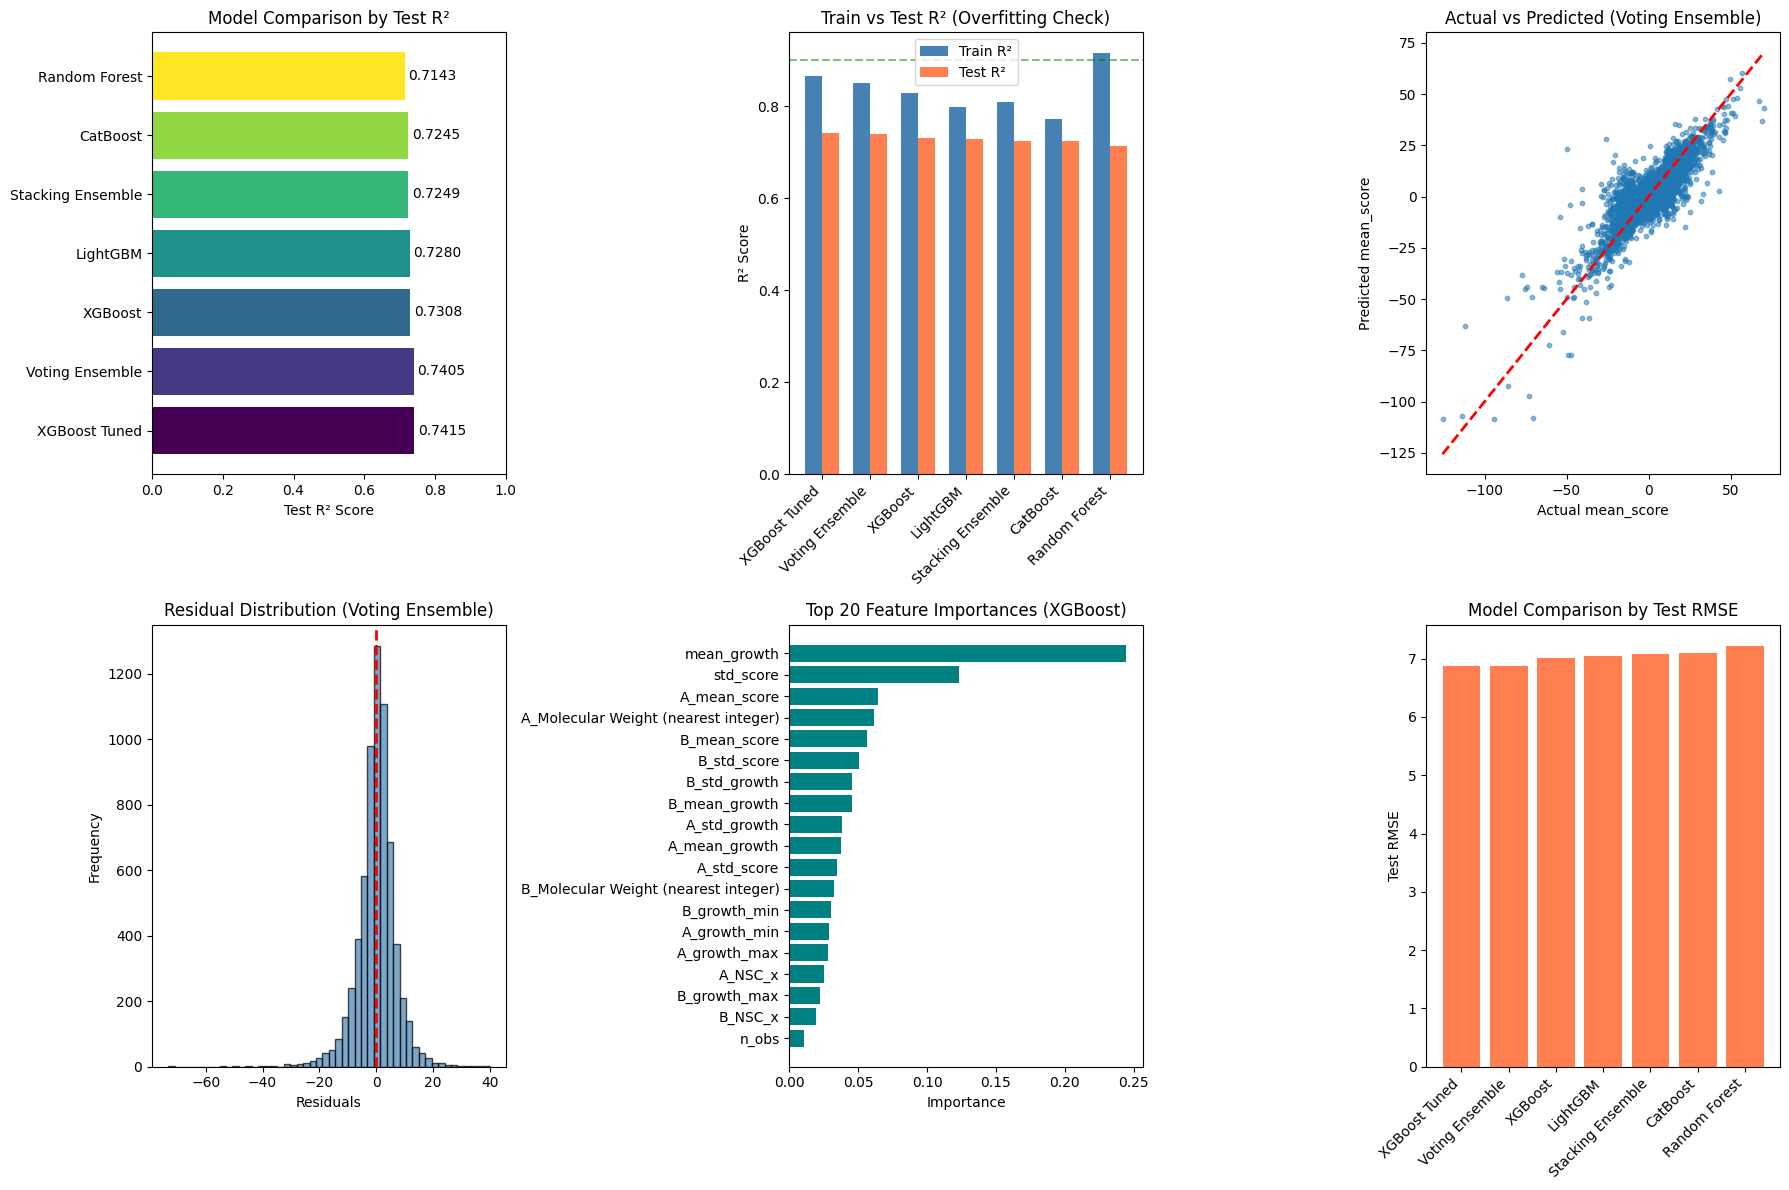

✅ Visualizations saved to 'model_comparison_results.png'


In [ ]:
# Step 7.2: Visualizations
print("=" * 60)
print("GENERATING VISUALIZATIONS")
print("=" * 60)

fig, axes = plt.subplots(2, 3, figsize=(18, 12))

# 1. Model Comparison Bar Chart
ax1 = axes[0, 0]
models = results_df['Model'].values
test_r2 = results_df['Test R²'].values
colors = plt.cm.viridis(np.linspace(0, 1, len(models)))
bars = ax1.barh(models, test_r2, color=colors)
ax1.set_xlabel('Test R² Score')
ax1.set_title('Model Comparison by Test R²')
ax1.set_xlim([0, 1])
for i, (bar, val) in enumerate(zip(bars, test_r2)):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.4f}', va='center')

# 2. Train vs Test R² (Overfitting Check)
ax2 = axes[0, 1]
x_pos = np.arange(len(results_df))
width = 0.35
ax2.bar(x_pos - width/2, results_df['Train R²'], width, label='Train R²', color='steelblue')
ax2.bar(x_pos + width/2, results_df['Test R²'], width, label='Test R²', color='coral')
ax2.set_xticks(x_pos)
ax2.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax2.set_ylabel('R² Score')
ax2.set_title('Train vs Test R² (Overfitting Check)')
ax2.legend()
ax2.axhline(y=0.9, color='green', linestyle='--', alpha=0.5, label='Good threshold')

# 3. Actual vs Predicted (Best Classical Model)
ax3 = axes[0, 2]
ax3.scatter(y_test, voting_pred, alpha=0.5, s=10)
ax3.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
ax3.set_xlabel('Actual mean_score')
ax3.set_ylabel('Predicted mean_score')
ax3.set_title('Actual vs Predicted (Voting Ensemble)')

# 4. Residual Distribution
ax4 = axes[1, 0]
residuals = y_test - voting_pred
ax4.hist(residuals, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
ax4.axvline(x=0, color='red', linestyle='--', lw=2)
ax4.set_xlabel('Residuals')
ax4.set_ylabel('Frequency')
ax4.set_title('Residual Distribution (Voting Ensemble)')

# 5. Feature Importance (Top 20)
ax5 = axes[1, 1]
top_20 = feature_importance.head(20)
ax5.barh(top_20['feature'], top_20['importance'], color='teal')
ax5.set_xlabel('Importance')
ax5.set_title('Top 20 Feature Importances (XGBoost)')
ax5.invert_yaxis()

# 6. RMSE Comparison
ax6 = axes[1, 2]
ax6.bar(results_df['Model'], results_df['Test RMSE'], color='coral')
ax6.set_xticklabels(results_df['Model'], rotation=45, ha='right')
ax6.set_ylabel('Test RMSE')
ax6.set_title('Model Comparison by Test RMSE')

plt.tight_layout()
plt.savefig('model_comparison_results.png', dpi=150, bbox_inches='tight')
plt.show()

print("✅ Visualizations saved to 'model_comparison_results.png'")

In [ ]:
# Step 7.3: Final Results Summary
print("=" * 60)
print("FINAL RESULTS SUMMARY")
print("=" * 60)

print(f"""
╔══════════════════════════════════════════════════════════════╗
║                    DRUG SYNERGY PREDICTION                    ║
║                      FINAL RESULTS                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                               ║
║  📊 Dataset: {len(df):,} rows → {len(df_final):,} after preprocessing           
║                                                               ║
║  🏆 Best Classical Model: {best_model['Model']:<30}║
║     • Test R²:   {best_model['Test R²']:.4f}                              ║
║     • Test RMSE: {best_model['Test RMSE']:.4f}                              ║
║     • Test MAE:  {best_model['Test MAE']:.4f}                              ║
║                                                               ║
║  ⚛️  Quantum Model: {'Completed' if QUANTUM_SUCCESS else 'Not Available':<30}          ║
{'║     • Test R²: ' + f"{quantum_metrics['Test R²']:.4f}" if QUANTUM_SUCCESS else '║     (Quantum computing skipped)'}                              ║
║                                                               ║
║  ✅ Overfitting Status: {'Controlled ✓' if best_model['Overfit Gap'] < 0.05 else 'Warning ⚠️':<30}     ║
║     (Train-Test Gap: {best_model['Overfit Gap']:.4f})                          ║
║                                                               ║
╚══════════════════════════════════════════════════════════════╝
""")

# Save results to CSV
results_df.to_csv('model_results.csv', index=False)
print("✅ Results saved to 'model_results.csv'")

print("\n🎉 WORKFLOW COMPLETE!")

FINAL RESULTS SUMMARY

╔══════════════════════════════════════════════════════════════╗
║                    DRUG SYNERGY PREDICTION                    ║
║                      FINAL RESULTS                            ║
╠══════════════════════════════════════════════════════════════╣
║                                                               ║
║  📊 Dataset: 304,943 rows → 32,891 after preprocessing           
║                                                               ║
║  🏆 Best Classical Model: XGBoost Tuned                 ║
║     • Test R²:   0.7415                              ║
║     • Test RMSE: 6.8645                              ║
║     • Test MAE:  4.7496                              ║
║                                                               ║
║  ⚛️  Quantum Model: Not Available                           ║
║     (Quantum computing skipped)                              ║
║                                                               ║
║  ✅ Overfitting Status: 

In [ ]:
# Step 7.4: Save Best Model as PKL
import pickle

# Map display names to variable names used in the notebook
model_var_map = {
    'XGBoost': 'xgb_model',
    'Random Forest': 'rf_model',
    'LightGBM': 'lgb_model',
    'CatBoost': 'cat_model',
    'Voting Ensemble': 'voting_model',
    'Stacking Ensemble': 'stacking_model'
}

model_registry = {}
for display_name, var_name in model_var_map.items():
    if var_name in globals() and globals()[var_name] is not None:
        model_registry[display_name] = globals()[var_name]

# Prefer the actual tuned best estimator when available
if 'random_search' in globals() and hasattr(random_search, 'best_estimator_'):
    model_registry['XGBoost Tuned'] = random_search.best_estimator_
elif 'xgb_tuned' in globals() and xgb_tuned is not None:
    model_registry['XGBoost Tuned'] = xgb_tuned

best_model_name = results_df.iloc[0]['Model']
best_model_obj = model_registry.get(best_model_name)

if best_model_obj is None:
    available = ', '.join(sorted(model_registry.keys())) or 'None'
    raise ValueError(
        f"Best model '{best_model_name}' is not available in memory. Available: {available}"
    )

safe_name = best_model_name.lower().replace(' ', '_')
pkl_path = f"best_model_{safe_name}.pkl"

with open(pkl_path, 'wb') as f:
    pickle.dump(best_model_obj, f)

print(f"Saved best model: {best_model_name}")
print(f"File: {pkl_path}")


NameError: name 'model' is not defined